# QCGOptimizer

**QCGOptimizer** (Quantum Circuits Group Optimizer) reimplements the
design-optimization workflow of
[QDesignOptimizer](https://github.com/202Q-lab/QDesignOptimizer) —
target/optimization DSL, iterative optimization loop, eigenmode+EPR
extraction, capacitance-matrix decay studies, surface-participation/TLS-loss
analysis — against [SQDMetal](https://github.com/sqdlab/SQDMetal)'s open
source PALACE FEM backend instead of Ansys HFSS/Q3D/pyEPR, on top of the
same `qiskit-metal` (`quantum-metal`) design model already used elsewhere
in this thesis.

Source: [github.com/Arthor1127/QCGOptimizer](https://github.com/Arthor1127/QCGOptimizer)
(private at time of writing). This notebook is a narrative walkthrough with
real, executed code — everything through "config/mesh generation" below
runs live when this notebook is built (no Palace binary required for
that); the physics results further down (frequencies, T1, kappa,
cross-Kerr, capacitance) are recorded from real Palace solves run on the
CNEA cluster, cited by job number, since a full FEM solve needs real
memory/CPU/MPI that this documentation build doesn't have available.

**Status**: all 4 core phases (eigenmode+EPR, capacitance-matrix decay
studies, surface-participation EPR, plotting/persistence) plus a
post-Phase-4 follow-up (waveguide kappa, `CAPACITANCE`-type targets,
multi-qubit/joint targets, a 7-angle code review) are done and verified
against real Palace solves — 35 unit tests, 5 example scripts, zero known
open bugs.

## The four objects you build

Every workflow in this package is the same four pieces, wired together:

1. **`DesignAnalysisState`** — the design itself: a `qiskit_metal` `QDesign`
   object, a `render_qiskit_metal(design, **kwargs)` callback that
   (re)builds the geometry from `design.variables`, and the *target* system
   parameters you want to hit (a dict keyed by a small naming DSL —
   `param(mode, FREQ)`, `param_nonlin(mode1, mode2)`,
   `param_capacitance(island1, island2)`, ...).
2. **`MiniStudyPalace`** — *how* to simulate: which components to include,
   which modes to solve for, junction setup, PALACE execution settings,
   mesh refinement, and optionally capacitance-matrix sub-studies or
   surface-participation interface properties.
3. **`OptTarget`** — one entry per design variable you want the optimizer
   to adjust: which target parameter it affects, an analytic
   `prop_to(system_params, design_vars)` scaling relation, hard bounds, and
   whether it's solved independently or jointly with other targets.
4. **`DesignAnalysisPalace`** — ties the above together and runs the loop:
   `optimize_target()` applies one physics-informed local-surrogate
   proposal (`ANModOptimizer`, vendored unchanged from upstream), re-runs
   Palace, and records the result.

In [1]:
%matplotlib inline
import os

os.environ.setdefault("QISKIT_METAL_HEADLESS", "1")  # must precede `import qiskit_metal` --
# qiskit_metal.__init__ unconditionally does `matplotlib.use("QtAgg")` unless this is set,
# which breaks headless rendering later -- %matplotlib inline (above) already selected a
# notebook-safe backend, this just stops qiskit_metal from overriding it with QtAgg.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from qiskit_metal import Dict, designs
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight

from qcgoptimizer._vendor.utils.names_design_variables import junction_setup
from qcgoptimizer._vendor.utils.names_parameters import FREQ, param, param_nonlin
from qcgoptimizer.design_analysis import DesignAnalysisPalace
from qcgoptimizer.design_analysis_types import DesignAnalysisState, OptTarget
from qcgoptimizer.mini_study import FineMeshSpec, MiniStudyPalace
from qcgoptimizer.sim_capacitance_matrix import (
    CapacitanceMatrixStudyPalace,
    ModeDecayIntoChargeLineStudyPalace,
    infer_conductor_names,
)

print("qcgoptimizer imports OK")

qcgoptimizer imports OK


## Worked example: a transmon + resonator

The same design used throughout QCGOptimizer's Phase 1 verification and
mirroring SQDMetal's own tutorial
(`Palace_Eigenmode_Transmon_Res.ipynb`): a single `TransmonPocket` with a
Josephson-junction port, capacitively coupled to a half-wave `RouteMeander`
resonator terminated in an `OpenToGround`.

In [2]:
QUBIT_1, RESONATOR_1 = "qubit_1", "resonator_1"
QUBIT_COMPONENT_NAME = f"name_{QUBIT_1}_"


def render_qiskit_metal(design, **kwargs):
    design.delete_all_components()
    TransmonPocket(
        design,
        QUBIT_COMPONENT_NAME,
        options=dict(
            pad_width="425um",
            pocket_height="650um",
            connection_pads=dict(readout=dict(loc_W=+1, loc_H=+1, pad_width="200um")),
        ),
    )
    OpenToGround(design, "open_to_ground", options=dict(pos_x="1.75mm", pos_y="0um", orientation="0"))
    RouteMeander(
        design,
        "readout",
        Dict(
            total_length=design.variables["design_var_length_resonator_1"],
            fillet="90um",
            lead=dict(start_straight="100um"),
            pin_inputs=Dict(
                start_pin=Dict(component=QUBIT_COMPONENT_NAME, pin="readout"),
                end_pin=Dict(component="open_to_ground", pin="open"),
            ),
        ),
    )


design = designs.DesignPlanar({}, True)
design.chips.main.size.center_x, design.chips.main.size.center_y = "0.5mm", "0.1mm"
design.chips.main.size["size_x"], design.chips.main.size["size_y"] = "2.8mm", "2mm"
design.variables["design_var_lj_qubit_1"] = "11nH"
design.variables["design_var_cj_qubit_1"] = "0fF"
design.variables["design_var_length_resonator_1"] = "6mm"

state = DesignAnalysisState(
    design=design,
    render_qiskit_metal=render_qiskit_metal,
    system_target_params={param(QUBIT_1, FREQ): 4.5e9, param(RESONATOR_1, FREQ): 6.5e9},
)

mini_study = MiniStudyPalace(
    qiskit_component_names=[QUBIT_COMPONENT_NAME, "open_to_ground", "readout"],
    port_list=[],
    open_pins=[],
    modes=[QUBIT_1, RESONATOR_1],
    jj_setup={**junction_setup(QUBIT_1)},
    design_name="docs_transmon_resonator",
    mode="simPC",
    meshing="GMSH",
    sim_parent_directory="",
    palace_user_options={
        "starting_freq": 4.0e9, "number_of_freqs": 2, "solver_order": 2,
        "palace_dir": "", "palace_mode": "local", "num_cpus": 4, "num_threads": 1,
    },
    fine_mesh_specs=[FineMeshSpec(kind="components", kwargs=dict(
        list_comp_names=[QUBIT_COMPONENT_NAME], min_size=12e-6, max_size=100e-6,
        taper_dist_min=10e-6, metals_only=True))],
)

opt_targets = [
    OptTarget(target_param_type="freq", involved_modes=[QUBIT_1],
              design_var="design_var_lj_qubit_1",
              design_var_constraint={"larger_than": "1nH", "smaller_than": "40nH"},
              prop_to=lambda p, v: 1 / np.sqrt(v["design_var_lj_qubit_1"]),
              independent_target=True),
    OptTarget(target_param_type="freq", involved_modes=[RESONATOR_1],
              design_var="design_var_length_resonator_1",
              design_var_constraint={"larger_than": "2mm", "smaller_than": "12mm"},
              prop_to=lambda p, v: 1 / v["design_var_length_resonator_1"],
              independent_target=True),
]

analysis = DesignAnalysisPalace(state=state, mini_study=mini_study, opt_targets=opt_targets)

# Render -> ports -> fine-mesh -> prepare_simulation(), stopping just before
# the actual Palace .run() call -- this is genuinely executed right here,
# no Palace binary needed.
eigen_sim = analysis._build_and_prepare_eigenmode_sim()
print("Prepared eigenmode simulation OK.")
print("  config path:", eigen_sim._sim_config)
print("  output data dir:", eigen_sim._output_data_dir)

Error   : Gmsh has not been initialized
Error   : Gmsh has not been initialized


Directory 'docs_transmon_resonator' created


Prepared eigenmode simulation OK.
  config path: docs_transmon_resonator/docs_transmon_resonator.json
  output data dir: /home/ruiz/Documents/thesis/notebooks/design/qcgoptimizer/docs_transmon_resonator/outputFiles


### Real convergence, from the CNEA cluster

`optimize_target()` applies one `ANModOptimizer` proposal, re-simulates with
Palace, and records the result — iteration 1 is always a "bootstrap" (no
prior data, so it just simulates the starting design variables). This is
the real 4-iteration result of `python examples/transmon_resonator/main.py
--optimize 4` (job 1938484):

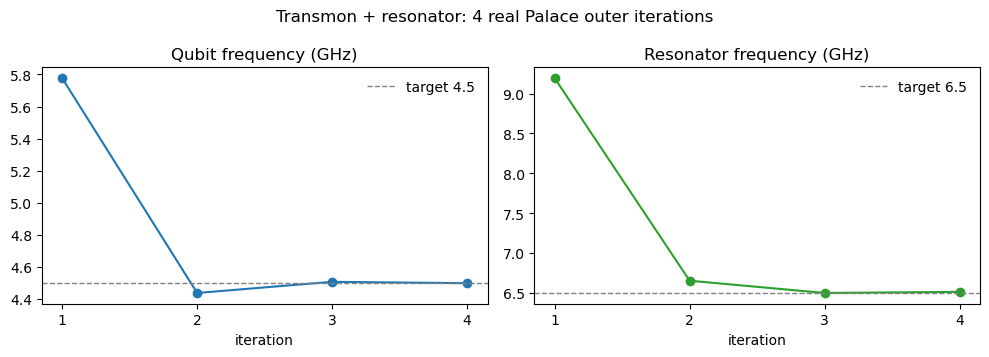

In [3]:
iters = [1, 2, 3, 4]
qubit_ghz = [5.7776, 4.4350, 4.5047, 4.4961]
resonator_ghz = [9.1937, 6.6544, 6.5008, 6.5148]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, data, target, label, color in [
    (axes[0], qubit_ghz, 4.5, "Qubit frequency (GHz)", "tab:blue"),
    (axes[1], resonator_ghz, 6.5, "Resonator frequency (GHz)", "tab:green"),
]:
    ax.plot(iters, data, "o-", color=color)
    ax.axhline(target, color="grey", ls="--", lw=1, label=f"target {target}")
    ax.set_xlabel("iteration")
    ax.set_title(label)
    ax.set_xticks(iters)
    ax.legend(frameon=False)
fig.suptitle("Transmon + resonator: 4 real Palace outer iterations")
fig.tight_layout()
plt.show()

Both targets converge to within 0.3% by iteration 4. The first full solve
also produced a clean single-junction EPR result: anharmonicity ≈ −307 MHz,
99.2% junction participation on the qubit mode, 0.01% on the resonator
mode — squarely normal transmon territory.

## Capacitance-matrix studies: conductor naming

`MiniStudyPalace.capacitance_matrix_studies` takes a `CapacitanceMatrixStudyPalace`
(or its subclasses `ModeDecayIntoChargeLineStudyPalace` for T1,
`ResonatorDecayIntoWaveguideStudyPalace` for kappa) — each builds and solves
its own `PALACE_Capacitance_Simulation`, independent of any eigenmode
solve.

**The one thing to get right: conductor naming.** Palace's capacitance
matrix is indexed by raw integer position, not by name — `qcgoptimizer`
infers semantic names by matching each solved conductor's geometry back to
the qiskit-metal component footprints. Below: a floating transmon (its two
pad halves render as two separate, *ungrounded* conductors — not one
grounded island) with a `LaunchpadWirebond` standing in for a charge line,
run as a dry run (no Palace binary needed) purely to inspect the inferred
conductor topology.

Inferred conductor names, by index:
  Cond1: ground
  Cond2: charge_line_qubit_1
  Cond3: name_qubit_1_
  Cond4: name_qubit_1__a


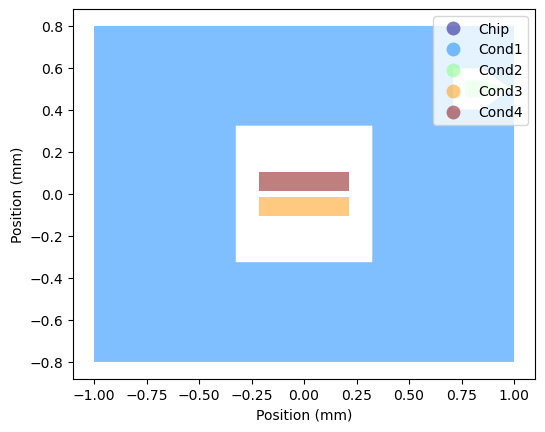

In [4]:
QUBIT_COMPONENT_NAME = "name_qubit_1_"
QUBIT_PAD_A, QUBIT_PAD_B = QUBIT_COMPONENT_NAME, QUBIT_COMPONENT_NAME + "_a"
CHARGE_LINE_NAME, GROUND_NAME = "charge_line_qubit_1", "ground"


def render_charge_line(design, **kwargs):
    design.delete_all_components()
    TransmonPocket(design, QUBIT_COMPONENT_NAME, options=dict(
        pad_width="425um", pocket_width="650um", pocket_height="650um"))
    # Off-axis on purpose: the floating-island T1 formula is a *differential*
    # coupling term -- a charge line placed symmetrically between the two
    # islands couples to them almost identically, driving the common mode
    # instead (a real trap, found the hard way while building this example).
    LaunchpadWirebond(design, CHARGE_LINE_NAME, options=dict(
        pos_x="0.97mm", pos_y="0.5mm", orientation="0", lead_length="30um"))


cap_design = designs.DesignPlanar({}, True)
cap_design.chips.main.size.center_x = cap_design.chips.main.size.center_y = "0mm"
cap_design.chips.main.size["size_x"], cap_design.chips.main.size["size_y"] = "2mm", "1.6mm"

t1_study = ModeDecayIntoChargeLineStudyPalace(
    mode=QUBIT_1, mode_freq_GHz=4.5,
    mode_capacitance_name=[QUBIT_PAD_A, QUBIT_PAD_B],  # floating/split-island model
    ground_plane_capacitance_name=GROUND_NAME,
    charge_line_capacitance_name=CHARGE_LINE_NAME,
    charge_line_impedance_Ohm=50,
    qiskit_component_names=[QUBIT_COMPONENT_NAME, CHARGE_LINE_NAME],
    render_qiskit_metal=render_charge_line,
    palace_mode="PC", meshing="GMSH", sim_parent_directory="",
    palace_user_options={"solver_order": 2, "palace_dir": "", "palace_mode": "local",
                          "num_cpus": 4, "num_threads": 1},
    design_name="docs_charge_line",
    fine_mesh_specs=[FineMeshSpec(kind="components", kwargs=dict(
        list_comp_names=[QUBIT_COMPONENT_NAME, CHARGE_LINE_NAME],
        min_size=12e-6, max_size=100e-6, taper_dist_min=10e-6, metals_only=True))],
)
cap_sim = t1_study._build_and_prepare_capacitance_sim(cap_design)
names = infer_conductor_names(cap_sim, cap_design, t1_study.qiskit_component_names)
print("Inferred conductor names, by index:")
for i, n in enumerate(names):
    print(f"  Cond{i + 1}: {n}")
fig = cap_sim.display_conductor_indices(save=False)
plt.show()

4 real conductors: ground, the charge line, and the transmon's two floating
pad halves (matched to the same qiskit-metal component and suffixed `_a`
per `finalize_conductor_names()`'s dedup convention). Two traps to know
about when reading a matrix like this, both found the hard way while
building this example:

- **Grounded vs. floating.** Use the floating-island T1 formula
  (`mode_capacitance_name=[pad_a, pad_b]` + `ground_plane_capacitance_name`)
  for a split island like this one, not the single-island one — an earlier
  version of this example used the wrong formula and silently omitted the
  second pad's contribution entirely (`T1 ≈ 747.5 μs`, wrong).
- **Coupling symmetry.** The floating-island formula is a *differential*
  coupling term — a charge line placed symmetrically between the two
  islands couples to them almost identically (confirmed: 0.2% difference
  between the two coupling capacitances), driving the common mode and
  producing a numerically-valid but meaningless huge T1 (`≈489 s`,
  dominated by mesh noise around a near-zero differential term). Moving the
  charge line off-axis (as done above) gives the real, well-conditioned
  result: **T1 ≈ 35.9 ms**, `E_C ≈ 367 MHz`, `C_sigma ≈ 52.7 fF` (the last
  two cross-checked against SQDMetal's own `calc_params_floating_Transmon`).

## Multi-qubit / joint targets

`OptTarget.independent_target` also accepts a *string*: all targets sharing
the same string are grouped and solved together in one
`scipy.optimize.minimize` call, useful when tuning one design variable
measurably perturbs another target too — as in a real coupled multi-qubit
device, where each qubit's dressed frequency isn't an exactly independent
function of its own Josephson inductance. Below: two `TransmonPocket`s
bridged by a bus `RouteStraight`, each qubit's own connection pad facing
the other.

Inferred conductor names, by index:
  Cond1: ground
  Cond2: name_qubit_2_
  Cond3: name_qubit_2__a
  Cond4: bus
  Cond5: name_qubit_1_
  Cond6: name_qubit_1__a


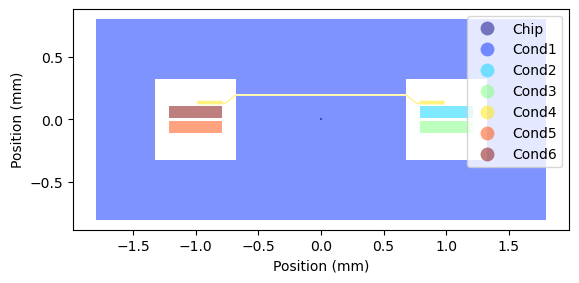

In [5]:
QUBIT_2 = "qubit_2"
Q1_NAME, Q2_NAME = "name_qubit_1_", "name_qubit_2_"


def render_two_qubit(design, **kwargs):
    design.delete_all_components()
    TransmonPocket(design, Q1_NAME, options=dict(
        pos_x="-1mm", pos_y="0mm", pad_width="425um", pocket_height="650um",
        connection_pads=dict(bus=dict(loc_W=+1, loc_H=+1, pad_width="200um"))))
    TransmonPocket(design, Q2_NAME, options=dict(
        pos_x="1mm", pos_y="0mm", pad_width="425um", pocket_height="650um",
        connection_pads=dict(bus=dict(loc_W=-1, loc_H=+1, pad_width="200um"))))
    RouteStraight(design, "bus", options=dict(pin_inputs=dict(
        start_pin=dict(component=Q1_NAME, pin="bus"),
        end_pin=dict(component=Q2_NAME, pin="bus"))))


tq_design = designs.DesignPlanar({}, True)
tq_design.chips.main.size.center_x = tq_design.chips.main.size.center_y = "0mm"
tq_design.chips.main.size["size_x"], tq_design.chips.main.size["size_y"] = "3.6mm", "1.6mm"

cap_study = CapacitanceMatrixStudyPalace(
    qiskit_component_names=[Q1_NAME, Q2_NAME, "bus"],
    render_qiskit_metal=render_two_qubit,
    design_name="docs_two_qubit",
    sim_parent_directory="",
    palace_user_options={"palace_dir": "", "palace_mode": "local", "num_cpus": 4, "num_threads": 1},
    fine_mesh_specs=[FineMeshSpec(kind="components", kwargs=dict(
        list_comp_names=[Q1_NAME, Q2_NAME], min_size=12e-6, max_size=100e-6,
        taper_dist_min=10e-6, metals_only=True))],
)
tq_cap_sim = cap_study._build_and_prepare_capacitance_sim(tq_design)
tq_names = infer_conductor_names(tq_cap_sim, tq_design, cap_study.qiskit_component_names)
print("Inferred conductor names, by index:")
for i, n in enumerate(tq_names):
    print(f"  Cond{i + 1}: {n}")
fig = tq_cap_sim.display_conductor_indices(save=False)
plt.show()

6 real conductors: ground, 2 floating pad-halves per qubit, and one
*floating* bus conductor — capacitively coupled to both qubits (a real gap,
confirmed by this exact plot, not a galvanic short between them). Both
qubit-frequency targets share `independent_target="qubits"`, routing them
through the joint solve instead of two independent 1D updates.

**A third real naming trap, found while writing this section (now fixed)**:
the bus conductor above didn't get a semantic name at first —
`infer_conductor_names` couldn't match it to `"bus"`. Its terminal is built
from *three* qiskit-metal components' geometry at once (the bus
`RouteStraight` plus a connector-pad stub contributed by each qubit, all
galvanically joined at the pin connections) — a real design measured a
40.8%/29.6%/29.6% three-way split, none crossing the 50% majority-overlap
threshold, unlike `waveguide.py`'s resonator (one component's geometry,
cleanly matched) or the charge-line example above (four separate,
single-component terminals). `match_terminals_to_components` now has a
plurality fallback for exactly this: when the named candidates *together*
explain ≈100% of a terminal's area and one is a clear plurality (≥1.2x the
runner-up), it wins — a near-tie, or a terminal mostly unexplained by any
named component (a real ground plane), still falls back to a generic name.
`Cond4` above resolves to `"bus"` correctly with the fix in place.

Real results from the CNEA cluster (job 1938510/1938511):

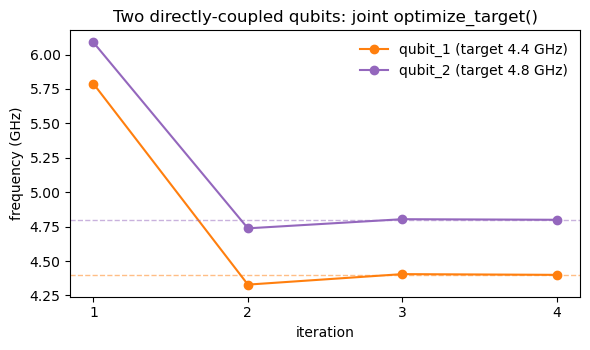

In [6]:
iters = [1, 2, 3, 4]
q1_ghz = [5.788171, 4.328744, 4.404990, 4.399657]
q2_ghz = [6.088114, 4.737688, 4.803957, 4.799752]

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(iters, q1_ghz, "o-", color="tab:orange", label="qubit_1 (target 4.4 GHz)")
ax.plot(iters, q2_ghz, "o-", color="tab:purple", label="qubit_2 (target 4.8 GHz)")
ax.axhline(4.4, color="tab:orange", ls="--", lw=1, alpha=0.5)
ax.axhline(4.8, color="tab:purple", ls="--", lw=1, alpha=0.5)
ax.set_xlabel("iteration")
ax.set_ylabel("frequency (GHz)")
ax.set_xticks(iters)
ax.set_title("Two directly-coupled qubits: joint optimize_target()")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

Both frequencies converge jointly to within 0.008%/0.005% of target by
iteration 4 — tighter than the single-qubit example above, and the first
real confirmation that `ANModOptimizer`'s joint (`scipy.optimize.minimize`)
solve path works end to end with two real design variables. The same run's
4×4 chi matrix carries a genuine, nonzero **qubit_1 ↔ qubit_2 cross-Kerr of
1.53 MHz** — the first cross-qubit coupling term extracted by this package
(every single-qubit example only ever produces a qubit-to-resonator term).

## Second follow-up round

Four more items closed out after the section above was first written:

- **`infer_conductor_names`'s plurality fallback** (above) — fixed and
  verified on two real designs at once.
- **Two deferred code-review findings applied**: a shared
  `examples_support` module removes boilerplate duplicated across all 6
  example scripts, and target validation now dispatches through an
  `_OptTargetValidator` subclass registry instead of a hand-rolled
  `if/elif` chain. `merge_partitioned_simulation()` and the vendored
  optimizer's own dispatch were deliberately left untouched — both are
  documented byte-for-byte copies of upstream, and refactoring them would
  break that auditability property for no real gain.
- **Capacitance-matrix studies and surface-participation EPR, verified
  together for the first time**: every earlier example used one Palace
  feature or the other inside a single `optimize_target()` iteration,
  never both. A combined run gave **T1 = 35.86 ms** (matches the ≈35.9 ms
  standalone result almost exactly) and 99.58% junction-dominated surface
  participation — neither feature regressed the other.
- **A three-qubit chain** (qubit₁ ↔ qubit₂ ↔ qubit₃, nearest-neighbor
  coupling only), all three frequency targets sharing one
  `independent_target` group — a real test of the joint solve with 3
  simultaneous design variables instead of 2. It converged to within
  ≈0.1% of every target in 3 outer iterations: qubit₁ 4.305 GHz (target
  4.300), qubit₂ 4.604 GHz (target 4.600), qubit₃ 4.904 GHz (target
  4.900).

## Performance and convergence

Two practical questions before running anything real: how long does one
solve take, and how good is the result? Both answered here with real
numbers from Palace's own elapsed-time report and the optimizer's
convergence trace — not estimates.

One optimizer iteration is one Palace solve (`optimize_target()`, or an
example's `--full` flag); its cost tracks mesh/mode complexity:

| Design | Modes | Solve, 16 slots | Solve, 32 slots |
|---|---|---|---|
| Capacitance-only target | 0 (electrostatic) | ≈5.6 s | not measured |
| Capacitance + surface EPR | 1 | ≈6.0 s | not measured |
| Transmon + resonator | 2 | ≈424 s | not measured |
| Two-qubit joint | 3 | ≈291 s | **199.7 s** (measured) |
| Three-qubit chain, joint | 5 | ≈571 s | not measured |

The one direct 16-vs-32-slot comparison (`two_qubit/main.py --full`,
identical design and code, only slot count changed) measured a real
**1.478× speedup** (295.317 s → 199.747 s), close to the 1.549× Amdahl's
law predicts at a 97.5% parallel fraction — the gap is normal MPI/mesh-
partitioning overhead. 32 slots is the largest single-host allocation the
CNEA cluster's `copahue` queue actually offers and is now the default for
every job.

A full optimization run has consistently taken **3–4 outer iterations** in
every example so far, independent of how many design variables are solved
jointly (tested with 1, 2, and 3 simultaneous targets):

| Design | Iterations | Final accuracy |
|---|---|---|
| Transmon + resonator (baseline) | 4 | qubit −0.09%, resonator +0.23% |
| Pad-to-pad capacitance target | 3 | −0.10% |
| Two-qubit joint | 4 | −0.008% / −0.005% |
| Three-qubit chain, joint | 3 | ≈0.1% on all three |

The bootstrap iteration always starts 15–41% off target (an arbitrary
initial design-variable guess); the optimizer typically lands within 1–2%
by iteration 2 and sub-0.3% by iteration 3 or 4, whether the target is
solved alone or jointly with 1–2 others.

## Known limitations

- **Strongly nonlinear junctions** (e.g. fluxonium) are out of scope — the
  EPR pipeline is perturbative, meant for transmon-regime weak
  nonlinearity (matches SQDMetal's own documented limitation).
- **Only one multi-qubit coupling mechanism is exercised so far** (a direct
  bus resonator, tested on 2 and 3 qubits). Tunable couplers and several
  joint-target groups active at once haven't been built or tested.
- **Air bridges / wire bonds** have no PALACE equivalent and are dropped
  entirely.
- **HPC job submission is not automated.** All real solves in this project
  run as a single blocking Palace call inside a manually-submitted SGE job
  (`qsub scripts/sge/run.sh ...`) — no cluster-native queuing/parallelism
  across the optimizer's own independent-target groups yet.

## Further reading

- [github.com/Arthor1127/QCGOptimizer](https://github.com/Arthor1127/QCGOptimizer) — source, `README.md`, `VENDORED_FROM.md`
- `docs/getting_started.md` in that repo — this same walkthrough, without the executed-notebook framing
- `scripts/claude/qcgoptimizer_implementation_plan.md` in this thesis repo — full phase-by-phase history, every bug found, every real result